In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta
import os

In [2]:
# Load in the daily measured heights of the wells in a dataframe and manage dates
df_heights = pd.read_csv('data/well_heights.csv')
df_heights['date'] = pd.to_datetime(df_heights['date'], format='%d-%m-%Y')
df_heights = df_heights.set_index('date')

well_elevations = [3.6, 3.301, 2.981]

In [3]:
# Sample data (well positions)
data = {
    'index': [112, 117, 123],
    'x': [642148.7330878308, 642146.5493111424, 642144.3655341836],
    'y': [1105249.5262411537, 1105247.3058195126, 1105245.08539804],
    'z': [3.6, 3.301, 2.981]
}

# Create a DataFrame
df_local_coordinates = pd.DataFrame(data)

df_local_coordinates['x'] -= df_local_coordinates['x'][0]
df_local_coordinates['y'] -= df_local_coordinates['y'][0]

new_column = []

for i in range(3):
    if i == 0:
        new_column.append(0)
    else:
        new_column.append(np.sqrt((df_local_coordinates['x'][i] - df_local_coordinates['x'][i-1])**2 + (df_local_coordinates['y'][i] - df_local_coordinates['y'][i-1])**2) + new_column[i-1])

df_local_coordinates['local_coord'] = new_column

display(df_local_coordinates)

,index,x,y,z,local_coord
0,112,0.000000,0.000000,3.600,0.000000
1,117,-2.183777,-2.220422,3.301,3.114346
2,123,-4.367554,-4.440843,2.981,6.228693


In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

def make_plots_section(date, time_fraction, ax):
    # Prepare the date string and load the well heights
    date_str = date.strftime('%Y%m%d')
    heights = pd.to_numeric(df_heights.loc[date].values, errors='coerce') / 100  # Convert to numeric and then divide by 100


    # Define file paths and load CSVs
    file_paths = [f'data/{date_str}/logger_{i+1:02d}.csv' for i in range(3)]
    dfs = [pd.read_csv(path, skiprows=1) if os.path.exists(path) else None for path in file_paths]

    # Process loaded CSVs and set datetime index
    for i, df in enumerate(dfs):
        if df is not None:
            df.columns = df.columns.str.strip()
            df['datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], format='%d-%m-%y %H:%M:%S', dayfirst=True)
            df.set_index('datetime', inplace=True)
        else:
            print(f"File {file_paths[i]} does not exist, skipping...")

    # Reverse the DataFrames order (Well 3 -> Well 2 -> Well 1)
    dfs = dfs[::-1]  
    middle_index = int(len(dfs[0]) // (1/time_fraction))
    datetime_requested = dfs[0].index[middle_index]
    time_requested = dfs[0].iloc[middle_index]['Time'].strip()

    # Prepare well elevations
    well_elevations_transformed = well_elevations - heights[::-1]
    local_coords = df_local_coordinates['local_coord']

    # Calculate water elevations
    water_elevations = [well_elevations[i] - 1.9 + dfs[i].loc[datetime_requested]['Meters'] for i in range(3)]

    # Create plot
    ax.plot(local_coords, well_elevations_transformed, color='sandybrown', label='Sand level', linewidth=2, marker='o')
    
    ax.plot(local_coords[1:], water_elevations[1:], linestyle=':', color='royalblue', label='Groundwater Table Elevation', linewidth=2)

    for i in range(2):
        ax.scatter(local_coords[i+1], water_elevations[i+1], color='royalblue')

        ax.annotate(f'{water_elevations[i+1]:.2f} m', 
                     (local_coords[i+1], water_elevations[i+1]),
                     textcoords="offset points",
                     xytext=(0, 10),  # Offset annotation above the point
                     ha='center', fontsize=12, color='black')

    # Mark wells with different colors and styles
    well_labels = ['Well 3', 'Well 2', 'Well 1']
    marker_styles = ['o', 's', 'D']
    marker_colors=['red', 'green', 'orange']
    for i in range(3):
        ax.scatter(local_coords[i], well_elevations[i], color=marker_colors[i], 
                    marker=marker_styles[i], s=100, label=well_labels[i])
        
        ax.annotate(f'{well_elevations[i]:.2f} m', 
                     (local_coords[i], well_elevations[i]),
                     textcoords="offset points",
                     xytext=(0, 10),  # Offset annotation above the point
                     ha='center', fontsize=12, color=marker_colors[i])

    # Final plot customizations
    ax.set_ylim(0, 4)
    ax.set_xlim(-1, 7)
    ax.set_xlabel("Local Coordinates (m)", fontsize=14)
    ax.set_ylabel("Elevation (m)", fontsize=14)
    ax.set_title(time_requested, fontsize=16)
    ax.grid(True, linestyle='--', alpha=0.7)

In [5]:
def make_subplots(date, time_fractions):
    date_display = date.strftime('%d-%m-%Y')
    date_str = date.strftime('%Y%m%d')

    n = len(time_fractions)
    ncols = int(n / 2)
    nrows = 2

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5 * ncols, 5 * nrows))

    axes = axes.flatten()

    for i in range(n):
        make_plots_section(date, time_fractions[i], axes[i])

    plt.legend()
    # fig.suptitle(f'Cross section of the beach over time on {date_display}', fontsize=18)

    plt.tight_layout()
    plt.savefig(f'plots/{date_str}-{n}_transect.png')

    plt.show()

In [6]:
date = '20241009'

date = datetime.strptime(date, '%Y%m%d')

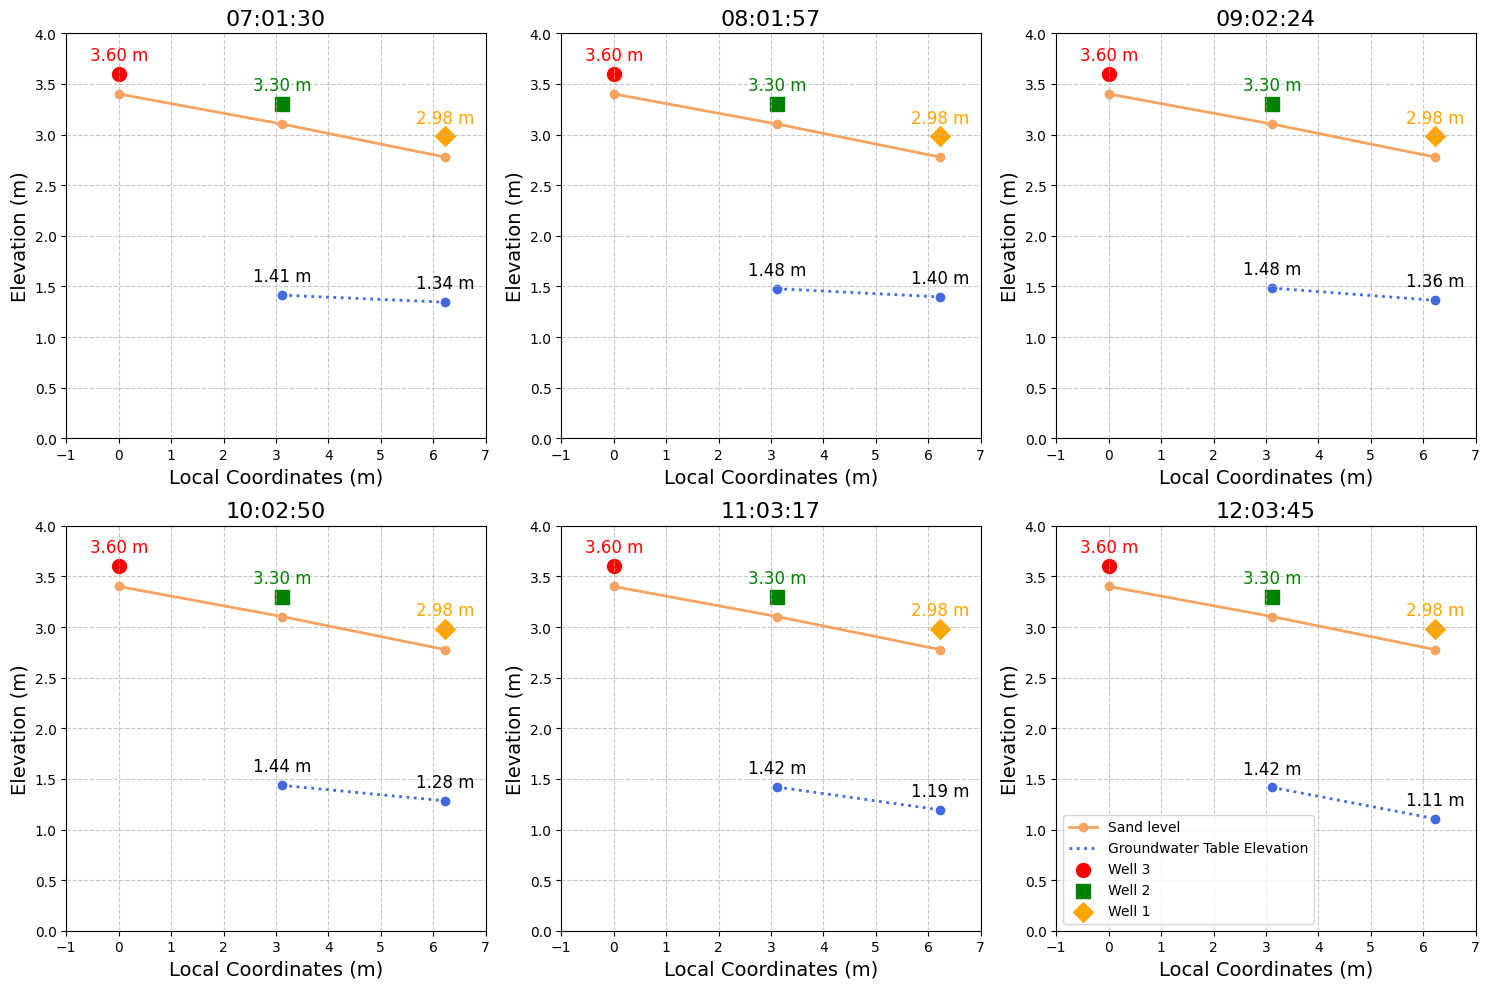

In [9]:
time_fractions = np.linspace(0.1, 0.75, 6)

make_subplots(date, time_fractions)